In [6]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt


In [7]:
etf = pd.read_csv(r"C:\Users\princ\Desktop\Python Project\Anonymized ETFs.csv")
main_assets = pd.read_csv(r"C:\Users\princ\Desktop\Python Project\Main Asset Classes.csv", skiprows=3)
myst1 = pd.read_csv(r"C:\Users\princ\Desktop\Python Project\Mystery Allocation 1.csv", header=None, names=["Date", "Value"])
myst2 = pd.read_csv(r"C:\Users\princ\Desktop\Python Project\Mystery Allocation 2.csv", header=None, names=["Date", "Value"])

### QUESTION 1

In [8]:
if etf.index.name == "Date":
    etf = etf.reset_index()

etf = etf.rename( columns= {etf.columns[0]: "Date"})
etf["Date"]  = pd.to_datetime(etf["Date"], dayfirst=True, errors="coerce")
for c in etf.columns[1:]:
    etf[c] = pd.to_numeric(etf[c], errors="coerce")
etf = etf.dropna()
print(etf.columns)

Index(['Date', 'ETF 1 ', 'ETF 2', 'ETF 3', 'ETF 4', 'ETF 5', 'ETF 6', 'ETF 7',
       'ETF 8', 'ETF 9',
       ...
       'ETF 96', 'ETF 97', 'ETF 98', 'ETF 99', 'ETF 100', 'ETF 101', 'ETF 102',
       'ETF 103', 'ETF 104', 'ETF 105'],
      dtype='object', length=106)


C:\Users\princ\AppData\Local\Temp\ipykernel_31076\4130267541.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  etf["Date"]  = pd.to_datetime(etf["Date"], dayfirst=True, errors="coerce")


In [9]:
# Compute daily returns

etf = etf.set_index("Date")
etf.index = etf.index.normalize()

In [10]:
daily_returns = etf.pct_change().dropna()
print(daily_returns.head())

              ETF 1      ETF 2     ETF 3     ETF 4     ETF 5     ETF 6  \
Date                                                                     
2019-01-02  0.001272 -0.001473 -0.010113 -0.002512  0.000908 -0.004294   
2019-01-03 -0.024575 -0.014755 -0.006302 -0.013454 -0.006079 -0.023584   
2019-01-04  0.034334  0.027523  0.015593  0.025611  0.021628  0.036050   
2019-01-07  0.007011  0.008181  0.013232  0.008941 -0.003880  0.007600   
2019-01-08  0.009711  0.008362 -0.002487  0.006906  0.007446  0.010532   

               ETF 7     ETF 8     ETF 9    ETF 10  ...    ETF 96   ETF 97  \
Date                                                ...                      
2019-01-02  0.002041  0.003049  0.008061  0.000977  ... -0.013949  0.00000   
2019-01-03 -0.000915  0.005885 -0.027786  0.004214  ... -0.001572  0.00000   
2019-01-04 -0.003119 -0.008175  0.032749  0.005772  ...  0.024868 -0.01591   
2019-01-07 -0.001253  0.009610  0.002443  0.005750  ...  0.009099  0.02878   
2019-01-08 -0

In [11]:
# Compute mean and std , both daily and annual

mean_daily = daily_returns.mean()
std_daily = daily_returns.std()

mean_annual = mean_daily * 252
std_annual = std_daily * np.sqrt(252)

summary = pd.DataFrame(
    {"Mean Daily": mean_daily,
     "Std Daily": std_daily,
     "Mean Annual": mean_annual,
     "Std Annual": std_annual
})
# sort values of the dataframe using .sort_values(by= "what you want to sort for", ascending= False)
# The ascending is either True if you want from small to big number, False from big to small
classification_daily_performance = summary.sort_values(by="Mean Daily", ascending=False)
classification_annual_performance = summary.sort_values(by="Mean Annual", ascending=False)
classification_daily_risk = summary.sort_values(by="Std Daily", ascending=False)
classification_annual_risk = summary.sort_values(by="Std Annual", ascending=False)

print(classification_daily_performance)
print(classification_annual_performance)
print(classification_daily_risk)
print(classification_annual_risk)


        Mean Daily  Std Daily  Mean Annual  Std Annual
ETF 53    0.001087   0.016891     0.274014    0.268144
ETF 12    0.000916   0.015619     0.230897    0.247942
ETF 74    0.000893   0.015620     0.225089    0.247961
ETF 23    0.000724   0.013386     0.182459    0.212499
ETF 58    0.000712   0.012956     0.179537    0.205665
...            ...        ...          ...         ...
ETF 20   -0.000026   0.003530    -0.006518    0.056044
ETF 90   -0.000032   0.003926    -0.008150    0.062329
ETF 39   -0.000044   0.003857    -0.011022    0.061228
ETF 70   -0.000044   0.003766    -0.011141    0.059788
ETF 91   -0.000056   0.002906    -0.014152    0.046124

[105 rows x 4 columns]
        Mean Daily  Std Daily  Mean Annual  Std Annual
ETF 53    0.001087   0.016891     0.274014    0.268144
ETF 12    0.000916   0.015619     0.230897    0.247942
ETF 74    0.000893   0.015620     0.225089    0.247961
ETF 23    0.000724   0.013386     0.182459    0.212499
ETF 58    0.000712   0.012956     0.17953

In [12]:
corr = daily_returns.corr()
print(corr)

           ETF 1      ETF 2     ETF 3     ETF 4     ETF 5     ETF 6     ETF 7  \
ETF 1    1.000000  0.970142  0.430133  0.948501  0.559187  0.980034  0.188189   
ETF 2    0.970142  1.000000  0.550652  0.993864  0.675192  0.955915  0.233242   
ETF 3    0.430133  0.550652  1.000000  0.638203  0.541099  0.417309  0.213277   
ETF 4    0.948501  0.993864  0.638203  1.000000  0.696797  0.933876  0.245007   
ETF 5    0.559187  0.675192  0.541099  0.696797  1.000000  0.556784  0.107352   
...           ...       ...       ...       ...       ...       ...       ...   
ETF 101  0.971742  0.952785  0.432867  0.933843  0.583095  0.961633  0.196844   
ETF 102  0.326178  0.438422  0.971808  0.530709  0.429726  0.312944  0.180914   
ETF 103  0.446022  0.546452  0.566490  0.579907  0.481011  0.449802  0.557461   
ETF 104  0.624690  0.753241  0.564520  0.772483  0.862720  0.620784  0.184963   
ETF 105  0.966024  0.989534  0.536505  0.982188  0.661078  0.947965  0.227191   

            ETF 8     ETF 9

In [14]:
# remove self-correlation (ETF with itself)
corr_pairs = corr.where(~np.eye(corr.shape[0], dtype=bool)).stack()

# Top 10 most correlated ETF pairs
top_corr = corr_pairs.sort_values(ascending=False).head(10)
print("\nMost correlated pairs:\n")
print(top_corr.to_string())

# 10 least correlated ETF pairs
low_corr = corr_pairs.sort_values(ascending=True).head(10)
print("\nLeast correlated pairs:\n")
print(low_corr.to_string())


Most correlated pairs:

ETF 51  ETF 14    0.999999
ETF 14  ETF 51    0.999999
ETF 60  ETF 89    0.999999
ETF 89  ETF 60    0.999999
ETF 12  ETF 74    0.999996
ETF 74  ETF 12    0.999996
ETF 25  ETF 47    0.999923
ETF 47  ETF 25    0.999923
ETF 57  ETF 78    0.999897
ETF 78  ETF 57    0.999897

Least correlated pairs:

ETF 55  ETF 90   -0.381476
ETF 90  ETF 55   -0.381476
ETF 56  ETF 90   -0.308603
ETF 90  ETF 56   -0.308603
        ETF 37   -0.304907
ETF 37  ETF 90   -0.304907
ETF 90  ETF 79   -0.272244
ETF 79  ETF 90   -0.272244
ETF 5   ETF 90   -0.267156
ETF 90  ETF 5    -0.267156


###### we can see how some ETF pairs have a correlation coefficient of 0.9999, this means that they basically track and represent the same asset class. In addiction there are some ETF pairs that have a negative correlation and this means that they represent different asset classes and that they move in opposite directions, providing a good and natural hedging solution in the portfolio. This can also reduce portfolio risk.

In [15]:
# Choose 4–5 ETFs with highest volatility as anchors (often equities/commodities)
anchors = summary.sort_values("Std Daily", ascending=False).head(5).index

group_map = {}
for etf_name in daily_returns.columns:
    best_anchor = corr.loc[etf_name, anchors].idxmax()
    group_map[etf_name] = best_anchor

relationship_groups = pd.Series(group_map, name="Most_Correlated_Anchor")
print("\nRelationship-based groups:\n")
print(relationship_groups.value_counts())


Relationship-based groups:

Most_Correlated_Anchor
ETF 13    56
ETF 53    35
ETF 74     9
ETF 75     4
ETF 12     1
Name: count, dtype: int64


### QUESTION 2

In [16]:
main_assets = main_assets.drop([0, 1])   # remove bad rows

# Rename column
main_assets = main_assets.rename(columns={main_assets.columns[0]: "Date"})

# Convert date
main_assets["Date"] = pd.to_datetime(main_assets["Date"], dayfirst=True, errors="coerce")

# Convert numeric values
for c in main_assets.columns[1:]:
    main_assets[c] = pd.to_numeric(main_assets[c], errors="coerce")

# Drop rows with missing values
main_assets = main_assets.dropna()

# Set index
main_assets = main_assets.set_index("Date")
main_assets.index = main_assets.index.normalize()

In [17]:
print(main_assets.head())

            SPTR500N Index  XNDX Index  RU20INTR Index  SX5T Index  \
Date                                                                 
2018-01-01         4672.65     7256.87       7554.1651     7048.52   
2018-01-02         4711.60     7387.98       7625.7417     7020.80   
2018-01-03         4741.75     7461.12       7638.4702     7060.42   
2018-01-04         4761.55     7472.49       7654.2279     7179.11   
2018-01-05         4795.03     7550.47       7675.4522     7257.05   

            TUKXG Index  NDUEEGF Index  NKYTR Index  IBOXIG Index  \
Date                                                                
2018-01-01      6519.85        521.047     35413.76      282.4644   
2018-01-02      6486.20        530.304     35413.76      280.7632   
2018-01-03      6505.71        533.125     35413.76      281.4011   
2018-01-04      6527.28        536.880     36567.09      281.2786   
2018-01-05      6551.31        540.695     36890.97      280.8513   

            IBOXHY Index 

###### SPTR500N Index = S&P 500 XNDX Index = Nasdaq 100 RU20INTR Index = US Small Caps SX5T Index = Euro Stoxx 50 TUKXG Index = UK FTSE NDUEEGF Index = MSCI EM NKYTR Index = Japan IBOXIG Index = US IG (Investment Grade) IBOXHY Index = US HY (High Yield)

###### QW5A Index = EU IG

###### IBOXXMJA Index = EU HY

###### JPEICORE Index = EM Bond

###### BCOMGCTR Index = Gold

###### BCOMTR Index = Commodity

In [18]:
print("Identicals Index :", etf.index.equals(main_assets.index))
print("Identicals Columns :", etf.columns.equals(main_assets.columns))

print("Missing Values in etf :", etf.isna().sum().sum())
print("Missing Values in main_assets :", main_assets.isna().sum().sum())


Identicals Index : False
Identicals Columns : False
Missing Values in etf : 0
Missing Values in main_assets : 0


In [19]:
main_returns = main_assets.pct_change().dropna()
print(main_returns.head())


            SPTR500N Index  XNDX Index  RU20INTR Index  SX5T Index  \
Date                                                                 
2018-01-02        0.008336    0.018067        0.009475   -0.003933   
2018-01-03        0.006399    0.009900        0.001669    0.005643   
2018-01-04        0.004176    0.001524        0.002063    0.016811   
2018-01-05        0.007031    0.010436        0.002773    0.010856   
2018-01-08        0.001675    0.003508        0.001164    0.002446   

            TUKXG Index  NDUEEGF Index  NKYTR Index  IBOXIG Index  \
Date                                                                
2018-01-02    -0.005161       0.017766     0.000000     -0.006023   
2018-01-03     0.003008       0.005320     0.000000      0.002272   
2018-01-04     0.003316       0.007043     0.032567     -0.000435   
2018-01-05     0.003681       0.007106     0.008857     -0.001519   
2018-01-08    -0.003587       0.004905     0.000000      0.000417   

            IBOXHY Index 

In [20]:
# Align the two datasets on the same dates
common_dates = daily_returns.index.intersection(main_returns.index)

etf_ret  = daily_returns.loc[common_dates]
main_ret = main_returns.loc[common_dates]

print(etf_ret.shape, main_ret.shape)

(1404, 105) (1404, 14)


In [21]:
corr_table = pd.DataFrame(
    index=etf_ret.columns,
    columns=main_ret.columns,
    dtype=float
)

for asset in main_ret.columns:
    corr_table[asset] = etf_ret.corrwith(main_ret[asset])

print(corr_table)

         SPTR500N Index  XNDX Index  RU20INTR Index  SX5T Index  TUKXG Index  \
ETF 1          1.000000    0.932432        0.874493    0.618015     0.559183   
ETF 2          0.970142    0.892318        0.873899    0.743013     0.675191   
ETF 3          0.430133    0.381451        0.411619    0.549935     0.541103   
ETF 4          0.948501    0.868894        0.857189    0.761092     0.696797   
ETF 5          0.559187    0.415521        0.561879    0.856170     1.000000   
...                 ...         ...             ...         ...          ...   
ETF 101        0.971742    0.876474        0.875913    0.637281     0.583095   
ETF 102        0.326178    0.308102        0.303958    0.439738     0.429733   
ETF 103        0.446022    0.377457        0.421874    0.523486     0.480982   
ETF 104        0.624690    0.521983        0.619851    0.993779     0.862719   
ETF 105        0.966024    0.894925        0.849650    0.732325     0.661080   

         NDUEEGF Index  NKYTR Index  IB

In [22]:
best_class = corr_table.idxmax(axis=1)
best_corr  = corr_table.max(axis=1)

etf_class_map = pd.DataFrame({
    "Best_Asset_Class": best_class,
    "Correlation": best_corr
})
print(etf_class_map)

        Best_Asset_Class  Correlation
ETF 1     SPTR500N Index     1.000000
ETF 2     SPTR500N Index     0.970142
ETF 3      NDUEEGF Index     0.998703
ETF 4     SPTR500N Index     0.948501
ETF 5        TUKXG Index     1.000000
...                  ...          ...
ETF 101   SPTR500N Index     0.971742
ETF 102    NDUEEGF Index     0.975568
ETF 103   JPEICORE Index     0.998963
ETF 104       SX5T Index     0.993779
ETF 105   SPTR500N Index     0.966024

[105 rows x 2 columns]


In [23]:
counts = etf_class_map["Best_Asset_Class"].value_counts()
print(counts)

Best_Asset_Class
SPTR500N Index    38
SX5T Index        19
QW5A Index        10
NDUEEGF Index      9
IBOXIG Index       8
XNDX Index         5
JPEICORE Index     5
NKYTR Index        3
IBOXXMJA Index     3
RU20INTR Index     2
TUKXG Index        1
BCOMGCTR Index     1
IBOXHY Index       1
Name: count, dtype: int64


### QUESTION 3

In [24]:
risk_stats = pd.DataFrame({
    "min" : summary["Std Annual"].min(),
    "max" : summary["Std Annual"].max(),
    "mean": summary["Std Annual"].mean(),
    "median": summary["Std Annual"].median(),
    "25%": summary["Std Annual"].quantile(0.25),
    "75%": summary["Std Annual"].quantile(0.75)
}, index=["Annual Volatility"])

print(risk_stats.T)

        Annual Volatility
min              0.000187
max              0.283230
mean             0.150099
median           0.169755
25%              0.086551
75%              0.201336


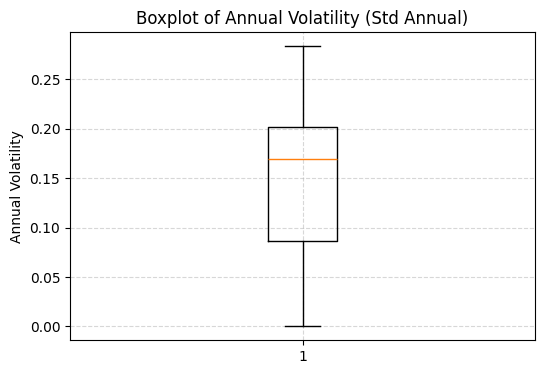

In [25]:
plt.figure(figsize=(6,4))
plt.boxplot(summary["Std Annual"], vert=True)
plt.title("Boxplot of Annual Volatility (Std Annual)")
plt.ylabel("Annual Volatility")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [26]:
print(summary.nsmallest(5, "Std Annual"))

        Mean Daily  Std Daily  Mean Annual  Std Annual
ETF 64   -0.000010   0.000012    -0.002432    0.000187
ETF 72    0.000082   0.000103     0.020780    0.001641
ETF 46    0.000033   0.000190     0.008432    0.003012
ETF 48    0.000117   0.000462     0.029438    0.007338
ETF 65    0.000024   0.000660     0.006089    0.010484


In [27]:
print(summary.nlargest(5, "Std Annual"))

        Mean Daily  Std Daily  Mean Annual  Std Annual
ETF 13    0.000590   0.017842     0.148704    0.283230
ETF 53    0.001087   0.016891     0.274014    0.268144
ETF 74    0.000893   0.015620     0.225089    0.247961
ETF 12    0.000916   0.015619     0.230897    0.247942
ETF 75    0.000607   0.015418     0.153001    0.244759


### QUESTION 4

In [28]:
# If 'Date' is currently the index, reset it to be a column
if myst1.index.name == 'Date':
    myst1 = myst1.reset_index()
# Convert date column to datetime
myst1["Date"] = pd.to_datetime(myst1["Date"], dayfirst=True, errors="coerce")

# Set Date column as index
myst1 = myst1.set_index("Date")

# Convert the value column (which is now the index) to numeric
# Access the single data column by its position [0]
myst1[myst1.columns[0]] = pd.to_numeric(myst1[myst1.columns[0]], errors="coerce")


myst1 = myst1.dropna()

myst1_returns = myst1.pct_change().dropna()

print(myst1_returns.head())

               Value
Date                
2019-01-02 -0.002066
2019-01-03 -0.013163
2019-01-04  0.018720
2019-01-07  0.005925
2019-01-08  0.005447


In [29]:
# Calculate daily and annual mean and std for myst1_returns
mean_daily_myst1 = myst1_returns.mean()
std_daily_myst1 = myst1_returns.std()

mean_annual_myst1 = mean_daily_myst1 * 252
std_annual_myst1 = std_daily_myst1 * np.sqrt(252)

# Print the results
print("Mysterious Allocation 1 Performance:")
print(f"Mean Daily Return: {mean_daily_myst1.iloc[0]:.6f}")
print(f"Standard Deviation Daily Return: {std_daily_myst1.iloc[0]:.6f}")
print(f"Mean Annual Return: {mean_annual_myst1.iloc[0]:.6f}")
print(f"Standard Deviation Annual Return: {std_annual_myst1.iloc[0]:.6f}")

Mysterious Allocation 1 Performance:
Mean Daily Return: 0.000504
Standard Deviation Daily Return: 0.008453
Mean Annual Return: 0.127046
Standard Deviation Annual Return: 0.134187


In [30]:
print(myst2.head())

         Date       Value
0  01/01/2019  100.000000
1  02/01/2019   99.606395
2  03/01/2019   98.154552
3  04/01/2019  100.950590
4  07/01/2019  101.682693


In [31]:
# If 'Date' is currently the index, reset it to be a column
if myst2.index.name == 'Date':
    myst2 = myst2.reset_index()

# Now 'Date' should always be a column
# Convert date column to datetime
myst2["Date"] = pd.to_datetime(myst2["Date"], dayfirst=True, errors="coerce")

# Drop rows with missing dates or values
myst2 = myst2.dropna()

# Set Date as index
myst2 = myst2.set_index("Date")

# Convert Value to numeric
# The value column is named 'Value' as per initial load
myst2["Value"] = pd.to_numeric(myst2["Value"], errors="coerce")

# Drop rows with missing values after numeric conversion
myst2 = myst2.dropna()

# Compute returns
myst2_returns = myst2.pct_change().dropna()

# Performance stats
mean_daily_myst2 = myst2_returns["Value"].mean()
std_daily_myst2 = myst2_returns["Value"].std()

mean_annual_myst2 = mean_daily_myst2 * 252
std_annual_myst2 = std_daily_myst2 * np.sqrt(252)

print("Mysterious Allocation 2 Performance:")
print(f"Mean Daily Return: {mean_daily_myst2:.6f}")
print(f"Std Daily Return: {std_daily_myst2:.6f}")
print(f"Mean Annual Return: {mean_annual_myst2:.6f}")
print(f"Std Annual Return: {std_annual_myst2:.6f}")

Mysterious Allocation 2 Performance:
Mean Daily Return: 0.000383
Std Daily Return: 0.010327
Mean Annual Return: 0.096474
Std Annual Return: 0.163943


In [32]:
# Correlation Mystery 1 vs ETFs

# Align the mystery allocation 1 and etf returns on common dates
common_dates_m1_etf = myst1_returns.index.intersection(daily_returns.index)
myst1_returns_aligned = myst1_returns.loc[common_dates_m1_etf]
daily_returns_aligned_m1 = daily_returns.loc[common_dates_m1_etf]

corr_m1 = daily_returns_aligned_m1.corrwith(myst1_returns_aligned["Value"])
top_m1 = corr_m1.sort_values(ascending=False).head(10)

In [33]:
# Correlation Mystery 2 vs ETFs

# Align the mystery allocation 2 and etf returns on common dates
common_dates_m2_etf = myst2_returns.index.intersection(daily_returns.index)
myst2_returns_aligned = myst2_returns.loc[common_dates_m2_etf]
daily_returns_aligned_m2 = daily_returns.loc[common_dates_m2_etf]

corr_m2 = daily_returns_aligned_m2.corrwith(myst2_returns_aligned["Value"])
top_m2 = corr_m2.sort_values(ascending=False).head(10)

In [34]:
asset_lookup = etf_class_map["Best_Asset_Class"].to_dict()

def print_mystery_interpretation(name, top_corr, asset_lookup):
    print(f"\nTop ETFs correlated with {name}:\n")
    for etf, corr in top_corr.items():
        asset_class = asset_lookup.get(etf, "Unknown Asset Class")
        print(f"{etf:<6}   {asset_class:<25}   Correlation: {corr:.4f}")

In [35]:
print_mystery_interpretation("Mystery Allocation 1", top_m1, asset_lookup)


Top ETFs correlated with Mystery Allocation 1:

ETF 59   SPTR500N Index              Correlation: 0.9820
ETF 2    SPTR500N Index              Correlation: 0.9814
ETF 94   SPTR500N Index              Correlation: 0.9806
ETF 22   SPTR500N Index              Correlation: 0.9784
ETF 77   SPTR500N Index              Correlation: 0.9773
ETF 4    SPTR500N Index              Correlation: 0.9769
ETF 92   SPTR500N Index              Correlation: 0.9747
ETF 18   SPTR500N Index              Correlation: 0.9743
ETF 105   SPTR500N Index              Correlation: 0.9736
ETF 17   SPTR500N Index              Correlation: 0.9732


In [36]:
print_mystery_interpretation("Mystery Allocation 2", top_m2, asset_lookup)


Top ETFs correlated with Mystery Allocation 2:

ETF 56   SX5T Index                  Correlation: 0.9138
ETF 4    SPTR500N Index              Correlation: 0.8953
ETF 22   SPTR500N Index              Correlation: 0.8909
ETF 18   SPTR500N Index              Correlation: 0.8797
ETF 94   SPTR500N Index              Correlation: 0.8757
ETF 71   SX5T Index                  Correlation: 0.8712
ETF 14   SX5T Index                  Correlation: 0.8711
ETF 51   SX5T Index                  Correlation: 0.8710
ETF 17   SPTR500N Index              Correlation: 0.8709
ETF 24   SX5T Index                  Correlation: 0.8707


### QUESTION 5

In [37]:
###### main bias is that most of the ETF are focused on US market and EU market, 
###### while emerging markets+gold+bonds are less represented. 
###### In addiction the commodities are forgotten among the Etf.